In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)


In [2]:
# Class 0
X_class0 = torch.randn(50, 2) + torch.tensor([-2.0, -2.0])

# Class 1
X_class1 = torch.randn(50, 2) + torch.tensor([2.0, 2.0])

# Combine the data
X = torch.cat([X_class0, X_class1], dim=0)

# Labels
y = torch.cat([torch.zeros(50),torch.ones(50)]).unsqueeze(1)

In [3]:
print('X shape',X.shape)
print('y shape',y.shape)

X shape torch.Size([100, 2])
y shape torch.Size([100, 1])


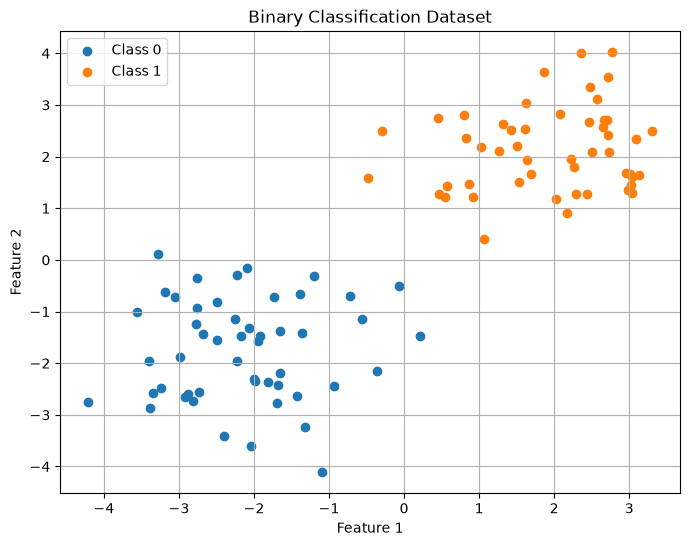

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_class0[:, 0],
    X_class0[:, 1],
    label="Class 0"
)

plt.scatter(
    X_class1[:, 0],
    X_class1[:, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")

plt.legend()
plt.grid(True)

plt.show()

In [5]:
class Logistic_Regression(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.linear = nn.Linear(2,1)

    def forward(self,X):
        z = self.linear(X)

        return torch.sigmoid(z)

In [6]:
model = Logistic_Regression()

loss_fn = nn.BCELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

In [7]:
epochs = 1000

for epoch in range(epochs):
    y_pred = model(X)

    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Loss: {loss.item():.4f}"
        )

Epoch    0 | Loss: 0.1852
Epoch  100 | Loss: 0.1077
Epoch  200 | Loss: 0.0790
Epoch  300 | Loss: 0.0638
Epoch  400 | Loss: 0.0542
Epoch  500 | Loss: 0.0476
Epoch  600 | Loss: 0.0427
Epoch  700 | Loss: 0.0389
Epoch  800 | Loss: 0.0358
Epoch  900 | Loss: 0.0333


In [8]:
with torch.no_grad():
    probabilities = model(X)

print(probabilities[:10])

tensor([[0.3655],
        [0.0019],
        [0.0046],
        [0.0013],
        [0.0371],
        [0.0012],
        [0.0024],
        [0.0121],
        [0.0493],
        [0.0108]])


In [9]:
predictions = (probabilities > 0.5).float()

print(predictions[:10])

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])


In [10]:
accuracy = (predictions == y).float().mean()

print(f"Accuracy: {accuracy.item() * 100:.2f}%")

Accuracy: 100.00%


In [11]:
with torch.no_grad():

    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = torch.meshgrid(
        torch.linspace(x_min, x_max, 200),
        torch.linspace(y_min, y_max, 200),
        indexing="ij"
    )

    grid = torch.stack(
        [xx.reshape(-1), yy.reshape(-1)],
        dim=1
    )

    probabilities = model(grid)

    predictions_grid = (probabilities >= 0.5).float()

    predictions_grid = predictions_grid.reshape(xx.shape)

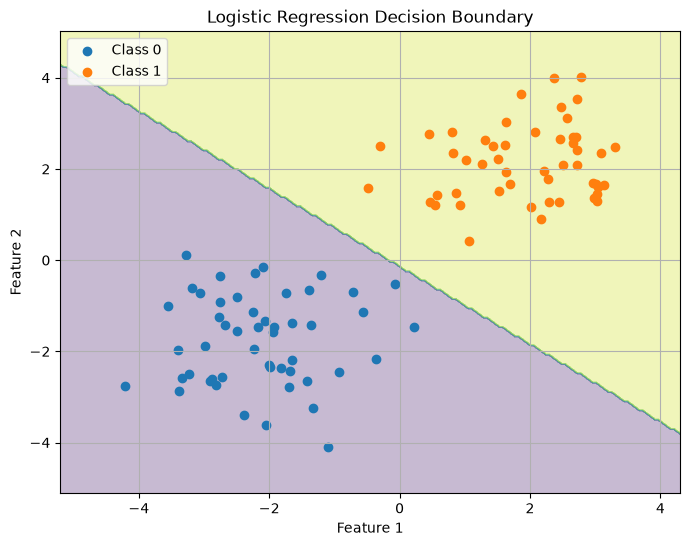

In [12]:
plt.figure(figsize=(8, 6))

plt.contourf(
    xx.numpy(),
    yy.numpy(),
    predictions_grid.numpy(),
    alpha=0.3
)

plt.scatter(
    X_class0[:, 0],
    X_class0[:, 1],
    label="Class 0"
)

plt.scatter(
    X_class1[:, 0],
    X_class1[:, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")

plt.legend()
plt.grid(True)

plt.show()